In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

# **Lab 7 - Deep learning based reduced order models (DL-ROMs)**

DL-ROMs are fully data-driven reduced order models that leverage on deep learning architectures to approximate the parameter-to-solution map. Here, we shall focus on a specific class of such approaches, namely: autoencoder-based DL-ROMs.

The idea is to replicate the computational pipeline of the POD-NN approach, but to replace the POD with an autoencoder. Let $\Theta\subset\mathbb{R}^{p}$ be the parameter space associated to a given parametrized PDE. Let $\mathbb{R}^{N_{h}}$ represent the high-fidelity space. Fix a latent dimension $n\ll N_{h}$. We look for three neural networks</br>

$$\Psi':\mathbb{R}^{N_h}\to\mathbb{R}^{n},\quad\quad\Psi:\mathbb{R}^{n}\to\mathbb{R}^{N_{h}},$$
</br>
$$\phi:\mathbb{R}^{p}\to\mathbb{R}^{n},$$

defined such that

$$\mathbf{u}_{\boldsymbol{\mu}}\approx\Psi(\Psi'(\mathbf{u}_{\boldsymbol{\mu}}))\quad\quad\text{and}\quad\quad
\phi(\boldsymbol{\mu})\approx\Psi'(\mathbf{u}_{\boldsymbol{\mu}}).$$

In its simplest implementation, this can be achieved through two consecutive training phases: the first one, concerns training the autoencoder; then, the encoder and the decoder are frozen, and $\phi$ is trained.

Once the two training have been carried out, the final model reads

$$\mathbf{u}_{\boldsymbol{\mu}}\approx \Psi(\phi(\boldsymbol{\mu})).$$
</br>

**Note**: for time-dependent problems, we set $\boldsymbol{\mu}:=[\tilde{\boldsymbol{\mu}},\;t]$, where $\tilde{\boldsymbol{\mu}}$ are the PDE parameters. That is, we treat the time variable, $t$, as an additional parameter.

## Example
As an example, we consider a very famous benchmark problem concerning a fluid flow past a cylinder. The latter is modeled using Navier-Stokes equations:

$$
\begin{cases}
\rho\left(\displaystyle \frac{\partial \boldsymbol{v}}{\partial t} + \boldsymbol{v}\cdot\nabla\boldsymbol{v}\right)-\epsilon\Delta \boldsymbol{v} + \nabla q = 0 & \text{in}\;\Omega\times(0,T],\\\\
\nabla\cdot\boldsymbol{v}= 0 & \text{in}\;\Omega\times(0, T],\\\\
\boldsymbol{v} = \boldsymbol{g} & \text{on}\;\Gamma_{\text{in}}\times(0, T]\;\cup\;\Omega\times\{0\},\\\\
\boldsymbol{v} = 0 & \text{on}\;\partial\Omega\setminus\left(\Gamma_{\text{in}}\cup\Gamma_{\text{out}}\right)\times(0, T],\\\\
q = 0 & \text{on}\;\Gamma_{\text{out}}\times(0, T]\end{cases}
$$

Here, $\epsilon>0$ is the dynamic viscosity and $\rho>0$ is the fluid density, whereas $\boldsymbol{v}:\Omega\times[0,T]\to\mathbb{R}^{2}$ is the fluid velocity field. For the sake of simplicity, we shall focus on the scalar field

$$u:=|\boldsymbol{v}|$$

describing the velocity magnitude across $\Omega$, where $|\cdot|$ is the Euclidean norm.
</br>
</br>
The script $\texttt{nstokes.py}$ provides a FOM solver for the above problem which, given $\epsilon$ and $\rho$, returns $u$. The solution is approximated using a P2 discretization in space. Only $N_t=141$ equispaced timesteps in $[0,T]=[0, 3.5]$ are returned. Since the FOM solver is quite expensive, a random dataset with $\log_{10}\epsilon\in[-3.5,\;-2.5]$ and $\rho\in[0.5,\;1]$ is provided.

In [2]:
# Downloading the dataset
import numpy as np
import gdown
gdown.download(id = "1Sj7sMVgrOv5dM4wYbiGCyDktFpdk8VGR", output = "nstokes_data.npz", quiet=False)
gdown.download(id = "1pkKBI4qGB2C6IGiXgAiY5CvZx0DEm88O", output = "nstokes_mesh.xml")
mesh = fe.loadmesh("nstokes_mesh.xml")
Vh = fe.space(mesh, 'CG', 2)
clc()

In [3]:
data = np.load("nstokes_data.npz")
mu, u = data['mu'], data['u']

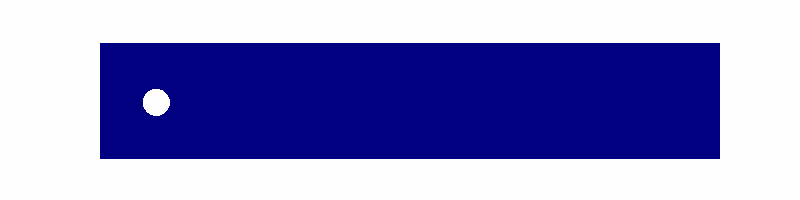

In [4]:
def visualize(uexample):
    fe.animate(uexample[::2], Vh, figsize = (8, 2))

visualize(u[0])

<mark>**Exercise 1**</mark></br>
Inspect and preprocess the dataset:

1. How many trajectories $N_s$ does it contain? What is the length (number of timesteps $N_t$) of each trajectory? What is $N_h$? What is $p$?</br></br>

2. Convert the data from numpy.arrays to torch.tensors. Let $t_{j}=jT/N_t$. Create a tensor a containg the "time-extended" parameters, i.e. $\texttt{mut}\in\mathbb{R}^{N_s\times N_t\times (p+1)}$ such that
$$\texttt{mut}_{i,j, .} = [\mu_{i,1},\;\mu_{i,2},\;t_j]$$
where $\mu_{i,1}$ and $\mu_{i,2}$ are the $\log_{10}\epsilon$ and the $\rho$ of the $i$-th simulated trajectory.</br></br>

3. Reshape the datasets $\texttt{u}$ and $\texttt{mut}$ to be of the form $\mathbb{R}^{(N_sN_t)\times N_h}$ and $\mathbb{R}^{(N_sN_t)\times (p+1)}$, respectively.

In [5]:
mu, u = dv.tensor(data['mu']), dv.tensor(data['u'])

ndata, ntimes, nh = u.shape
p = mu.shape[-1]
print("Trajectories:\t%d." % ndata)
print("Timesteps:\t%d." % ntimes)
print("FOM dimension:\t%d." % nh)
print("Parameters:\t%d." % p)


mut = dv.zeros(ndata, ntimes, p+1)
times = dv.tensor(np.linspace(0, 3.5, ntimes))
for i in range(ndata):
    mut[i,:,:2] = mu[i]
    mut[i,:, 2] = times

Trajectories:	41.
Timesteps:	141.
FOM dimension:	6477.
Parameters:	2.


In [6]:
u = u.reshape(-1, nh)
mut = mut.reshape(-1, p+1)

<mark>**Exercise 2**</mark></br>
Fix a suitable latent dimension $n$ and train an autoencoder over the dataset $\texttt{u}\in\mathbb{R}^{(N_sN_t)\times N_h}$. To this end, use half of the data, $\texttt{ntrain}=(N_s/2)N_t$. Evaluate its performances using the following error metric

$$E = \frac{1}{N_{\text{test}}}\sum_{i}\left(\frac{\int_{0}^{T}\|\mathbf{u}_{i}-\tilde{\mathbf{u}}_{i}\|_{L^{2}(\Omega)}}{\int_{0}^{T}\|\mathbf{u}_{i}\|_{L^{2}(\Omega)}}\right)$$

where $\|\cdot\|_{L^{2}(\Omega)}$ is the $L^{2}$-norm, whereas the index $i$ runs along the trajectories in the test set.

In [7]:
l2 = L2(Vh)
l2.cuda()
clc()

ntrain = (ndata//2)*ntimes

def error(utrue, upred):
    return (l2(utrue-upred).reshape(-1, ntimes).sum(axis = -1)/l2(utrue).reshape(-1, ntimes).sum(axis = -1)).mean()

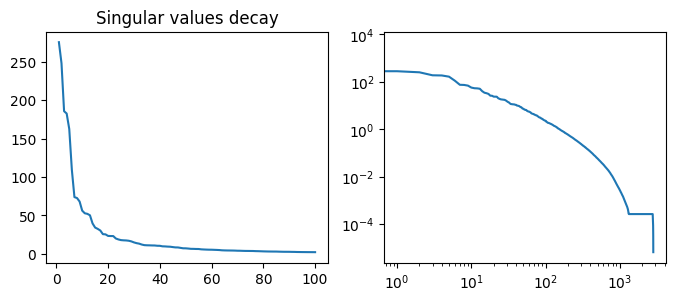

In [31]:
# Preliminary check to see if we actually need autoencoders!
from scipy.linalg import svd
import matplotlib.pyplot as plt

X, s, _ = svd(u[:ntrain].T.cpu().numpy(), full_matrices = False)
plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1)
plt.plot(1+np.arange(100), s[1:101])
plt.title("Singular values decay")
plt.subplot(1, 2, 2)
plt.loglog(s)
plt.show()

In [66]:
from torch.optim import Adam
rho_e = lambda x: relu(x) -10*relu(-x)
rho_d = lambda x: relu(x) -0.1*relu(-x)

latent = 7
encoder = Dense(nh, 50, rho_e) + Dense(50, latent, rho_e)
decoder = Dense(latent, 50, rho_d) + Dense(50, 100, rho_d) + Dense(100, nh, activation = None)
autoencoder = DFNN(encoder + decoder)

autoencoder.He()
autoencoder.cuda()

autoencoder.train(u, u, ntrain = ntrain, epochs = 30, loss = mse(l2),
                  error = error, notation = '%')

autoencoder.train(u, u, ntrain = ntrain, epochs = 2000, loss = mse(l2),
                  optim = Adam, lr = 1e-5, batchsize = 64,
                  error = error, notation = '%')

autoencoder.freeze()

		Train	Test
Epoch 2000:	1.65%	1.62%.

>> ETA: 0.23s.

Training complete. Elapsed time: 7 minutes 44.50 seconds.


In [67]:
print("Autoencoder MRE: %s" % num2p(error(u[ntrain:], autoencoder(u[ntrain:]))))

Autoencoder MRE: 1.62%


In [68]:
V = dv.tensor(X[: , :latent])
print("POD MRE: %s" % num2p(error(u[ntrain:], u[ntrain:] @ V @ V.T)))

POD MRE: 4.13%


<mark>**Exercise 3**</mark></br>
Freeze the autoencoder module and exploit the encoder to compress the dataset $\texttt{u}\in\mathbb{R}^{(N_sN_t)\times N_h}$ onto $\texttt{nu}\in\mathbb{R}^{(N_sN_t)\times n}$. Then, train a neural network model to learn the map from $\texttt{mut}\mapsto\texttt{nu}$.

After training, freeze the network and evaluate the performances of the whole DL-ROM using the same error metric as in Ex. 2.

In [77]:
nu = encoder(u)

from dlroms.dnns import Fourier
fmodes = 10
phi = DFNN(Fourier(fmodes, which=[-1]) + Dense(p+1+2*fmodes, 500, gelu) + Dense(500, latent, activation = None))

phi.He()
phi.cuda()
phi.train(mut, nu, ntrain = ntrain, epochs = 200, loss = mse(euclidean))
phi.freeze()

		Train		Test
Epoch 200:	5.02e+02	9.58e+02.

>> ETA: 0.28s.

Training complete. Elapsed time: 55.73 seconds.


In [78]:
dlrom = lambda mt: decoder(phi(mt))
num2p(error(u[ntrain:], dlrom(mut[ntrain:])))

'2.32%'

<mark>**Exercise 4**</mark></br>
Let $\log_{10}\epsilon = -2.95$ and $\rho = 0.73$. Simulate the fluid flow using both the FOM and the DL-ROM.

- Plot the two simulations: is the DL-ROM replicating the fluid flow correctly?

- How fast is the DL-ROM compared to the FOM?

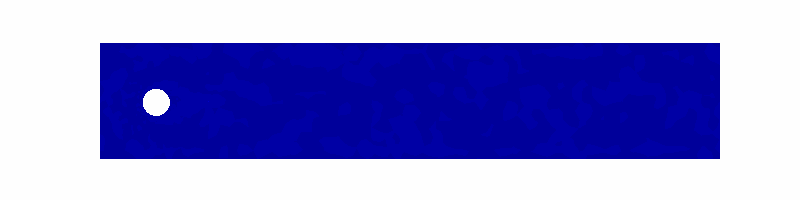

DL-ROM simulation time: 0.003s.


In [79]:
from time import perf_counter
mu0 = dv.tensor([-2.95, 0.73])

mu0t = dv.zeros(ntimes, p+1)
mu0t[:, 2] = times
mu0t[:, :2] = mu0

t0 = perf_counter()
uROM = dlrom(mu0t)
t1 = perf_counter()
visualize(uROM)
print("DL-ROM simulation time: %.3fs." % (t1-t0))

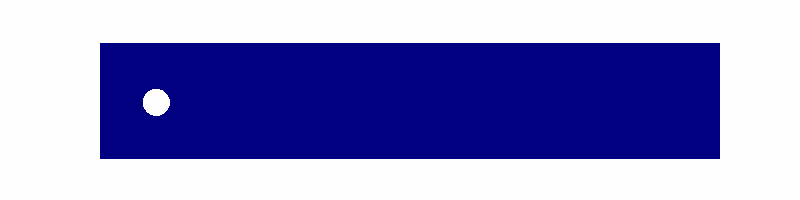

FOM simulation time: 300.466s.


In [14]:
from dlroms.testcases.cylinder import FOMsolver
t0 = perf_counter()
uFOM = FOMsolver(mu0.cpu().numpy())
t1 = perf_counter()
visualize(uFOM)
print("FOM simulation time: %.3fs." % (t1-t0))

In [80]:
autoencoder.save("ae.npz")
phi.save("phi.npz")